# Participation patterns in Swedish study association activities

## Executive summary

This project analyzes participation patterns in Swedish study association activities using official statistics from Statistics Sweden (SCB).

Key findings:

- Participation follows a clear life-cycle pattern, with peaks in early adulthood and around retirement age  
- The largest drop occurs around ages 25–29, during the transition into working life  
- Women participate more than men across all age groups  
- Higher education is associated with higher participation levels  
- The COVID-19 shock reduced participation levels, but did not change the underlying structure  

Overall, participation appears to be shaped by stable life-stage transitions rather than temporary external shocks.

## Main insight

Participation in Swedish study association activities follows a clear life-cycle pattern.

- Participation is relatively high in early adulthood (20–24)
- It drops sharply during the transition into work and family formation (25–29)
- It stabilizes and gradually increases through mid-life
- It peaks again around retirement age (65–74)
- It declines in the oldest age groups

In addition, there are clear gender differences:
- Women consistently show higher participation levels than men across most age groups

Participation is also positively associated with age up to retirement, suggesting that life stage plays a central role in shaping engagement in study association activities.

Despite the disruption caused by the COVID-19 pandemic in 2021, the overall life-cycle pattern remains visible, indicating that participation behavior is structurally stable over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

## Load the data

The dataset was downloaded from Statistics Sweden (SCB). Because Swedish CSV files often contain special characters, the file is read using latin-1 encoding.

In [2]:
df = pd.read_csv("TAB4477_sv.csv", encoding="latin-1", sep=",")
df.head()

,verksamhetsform,verksamhetsregion,studieförbund,kön,utbildningsnivå,åldersgrupp,år,Deltagare
0,Totalt,00 Riket,Totalt,män,förgymnasial utbildning,samtliga åldrar,2020,38258
1,Totalt,00 Riket,Totalt,män,förgymnasial utbildning,samtliga åldrar,2021,24651
2,Totalt,00 Riket,Totalt,män,förgymnasial utbildning,samtliga åldrar,2022,28856
3,Totalt,00 Riket,Totalt,män,förgymnasial utbildning,samtliga åldrar,2023,28630
4,Totalt,00 Riket,Totalt,män,förgymnasial utbildning,samtliga åldrar,2024,26542


## Data description

The dataset contains official statistics on participation in Swedish study association activities between 2020 and 2024. Each observation represents the number of participation events, not unique individuals. This means that the same person may be counted multiple times if they participate repeatedly or in several activities.

The dataset includes the following variables:

- **verksamhetsform**: type of activity
- **verksamhetsregion**: geographic unit (national, county, or municipality)
- **studieförbund**: study association
- **kön**: gender
- **utbildningsnivå**: education level
- **åldersgrupp**: age group
- **år**: year
- **Deltagare**: number of participation events

A central methodological challenge is that several variables contain both detailed and aggregated categories. The data therefore requires careful filtering before analysis in order to avoid double counting or misleading comparisons.

## Measurement considerations

An important limitation is that the data measures participation events rather than unique individuals.

This has several implications:

- Individuals who participate frequently contribute more to the total count  
- Groups with higher engagement intensity may appear overrepresented  
- Differences between groups may reflect frequency of participation rather than number of participants  

As a result, the analysis should be interpreted as describing participation intensity rather than participation rates.

A more complete analysis would require population-adjusted measures or individual-level data.

##  Prepare the data

Before the analysis, the participant variable is converted to numeric format. The year variable is also converted to numeric format to simplify filtering and plotting.

In [3]:
df["Deltagare"] = pd.to_numeric(df["Deltagare"], errors="coerce")
df["utbildningsnivå"] = df["utbildningsnivå"].str.strip()
df["år"] = pd.to_numeric(df["år"], errors="coerce").astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30270240 entries, 0 to 30270239
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   verksamhetsform    object 
 1   verksamhetsregion  object 
 2   studieförbund      object 
 3   kön                object 
 4   utbildningsnivå    object 
 5   åldersgrupp        object 
 6   år                 int32  
 7   Deltagare          float64
dtypes: float64(1), int32(1), object(6)
memory usage: 1.7+ GB


##  Inspect the structure of the dataset

Before filtering, it is important to inspect the structure of the data.

This matters because the dataset includes:

- aggregate and disaggregated categories
- overlapping and non-overlapping age groups
- multiple geographic levels

These features mean that the dataset cannot be analyzed directly without preprocessing.

## Methodological challenges

This dataset contains several hierarchical and overlapping categories. Three issues are especially important:

1. Age groups include both non-overlapping categories (for example 20–24 and 25–29) and overlapping aggregates (for example 25–44, 45–64, and 65+).
2. Education includes both detailed levels and aggregate categories such as alla utbildningsnivåer (all education levels).
3. Region includes national, county, and municipal levels in the same dataset.

To ensure valid comparisons, the analysis uses carefully selected non-overlapping subsets depending on the question being studied.

## Data cleaning strategy

The data is filtered differently depending on the purpose of each analysis.

- For the age and gender analyses, national totals are used in order to focus on broad structural patterns.
- For the education analysis, aggregate and missing education categories are removed so that meaningful education groups can be compared directly.
- Overlapping age groups are excluded when age comparisons are made.
- Geographic levels are not mixed within the same analysis.

This strategy ensures that each section of the project is internally consistent and interpretable.

## Age analysis

The first part of the analysis examines whether participation follows a life-cycle pattern.

To make age groups comparable, only non-overlapping age categories are retained. The analysis uses national totals, total study association activity, total gender, and all education levels combined.

In [4]:
selected_ages = [
    "5-9 år", "10-14 år", "15-19 år", "20-24 år", "25-29 år", "30-34 år",
    "35-39 år", "40-44 år", "45-49 år", "50-54 år", "55-59 år", "60-64 år",
    "65-69 år", "70-74 år", "75-79 år", "80-84 år", "85-89 år", "90-94 år"
]

df_age = df[
    (df["verksamhetsform"] == "Totalt") &
    (df["verksamhetsregion"] == "00 Riket") &
    (df["studieförbund"] == "Totalt") &
    (df["kön"] == "totalt") &
    (df["utbildningsnivå"] == "alla utbildningsnivåer") &
    (df["åldersgrupp"].isin(selected_ages))
].copy()



In [5]:
pivot_age = df_age.pivot_table(
    index="år",
    columns="åldersgrupp",
    values="Deltagare",
    aggfunc="sum"
).sort_index()

pivot_age = pivot_age[selected_ages]

## Average participation by age group

To compare age groups directly, average participation across all years is calculated.

In [6]:
avg_participation = pivot_age.mean().sort_values(ascending=False)


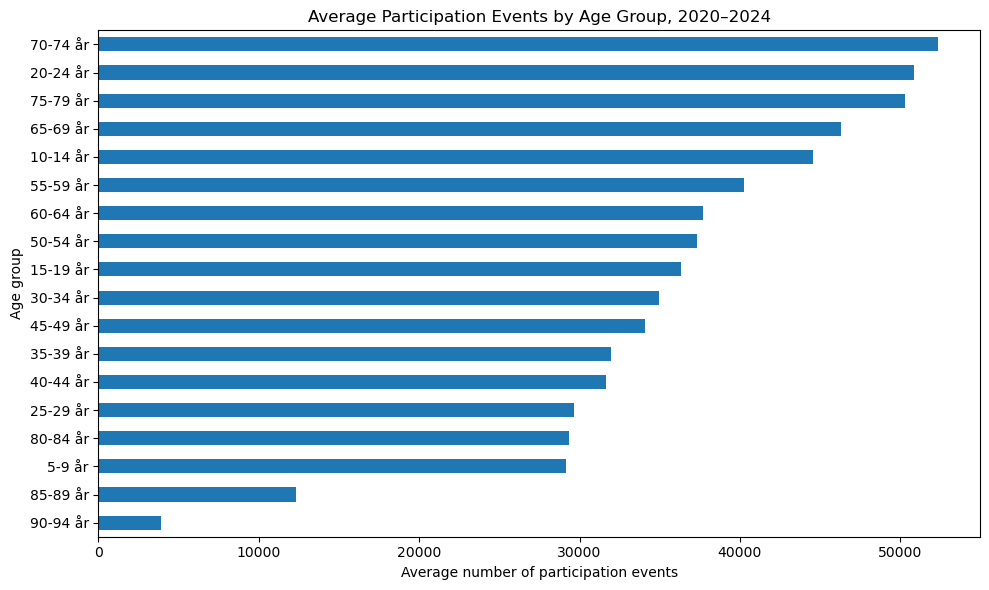

In [7]:
avg_participation.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Average Participation Events by Age Group, 2020–2024")
plt.xlabel("Average number of participation events")
plt.ylabel("Age group")
plt.tight_layout()
plt.show()

**Figure 1. Average participation by age group (2020–2024)**

The figure shows the average number of participation events across age groups.

Participation is highest among individuals aged 20–24 and 70–74, while lower levels are observed among young children and the oldest age groups. A noticeable decline appears in the 25–29 age group.

This pattern is consistent with a life-cycle interpretation: participation is relatively high in early adulthood, weaker during the transition into full working-age adulthood, and higher again around retirement age.

In [8]:
peak = avg_participation["20-24 år"]
dip = avg_participation["25-29 år"]

drop_pct = (peak-dip) / peak * 100
drop_pct

41.73114119922631

Participation drops by approximately 42% between ages 20–24 and 25–29, indicating a sharp structural transition during early adulthood.

## The life-cycle pattern

The figure below highlights the overall age pattern in participation.

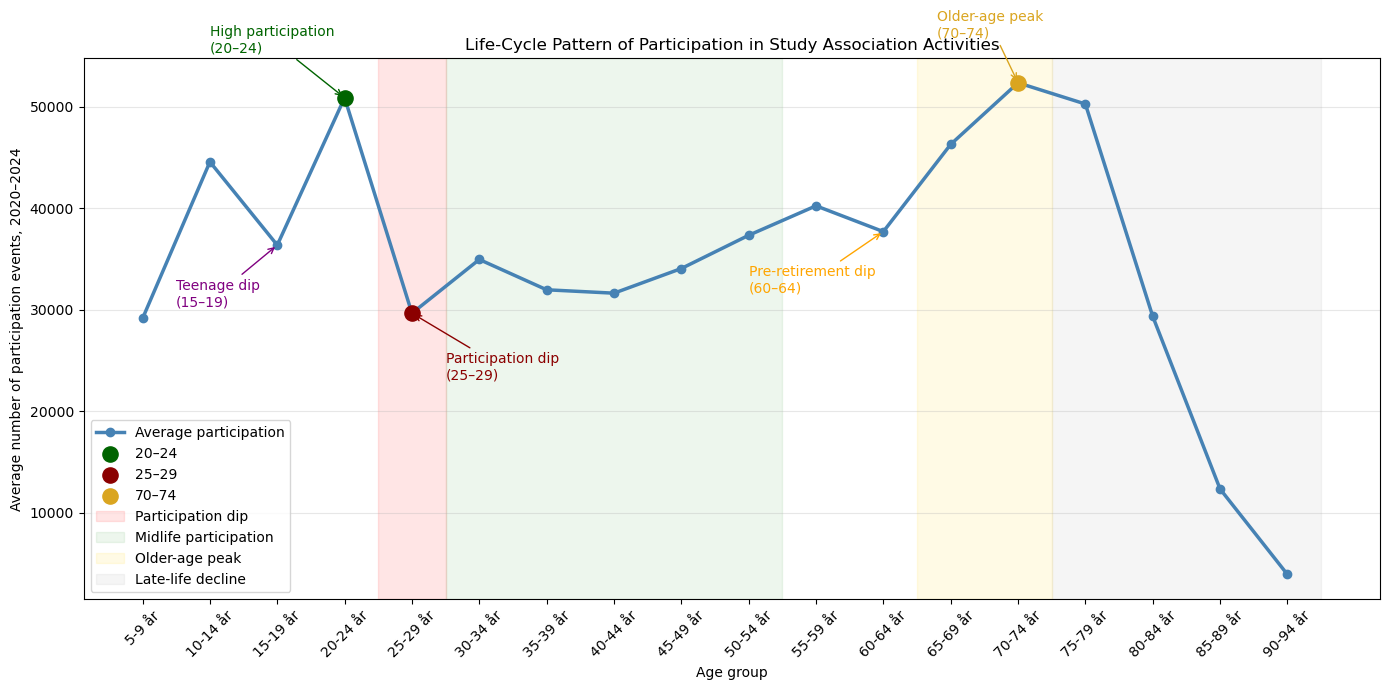

In [9]:
lifecycle = pivot_age.mean()
lifecycle = lifecycle[selected_ages]
x = np.arange(len(lifecycle))
y = lifecycle.values

plt.figure(figsize=(14, 7))

plt.plot(x, y, color="steelblue", linewidth=2.5, marker="o", label="Average participation")

idx_10_14 = selected_ages.index("10-14 år")
idx_15_19 = selected_ages.index("15-19 år")
idx_20_24 = selected_ages.index("20-24 år")
idx_25_29 = selected_ages.index("25-29 år")
idx_60_64 = selected_ages.index("60-64 år")
idx_70_74 = selected_ages.index("70-74 år")

plt.scatter(x[idx_20_24], y[idx_20_24], color="darkgreen", s=120, zorder=5, label="20–24")
plt.scatter(x[idx_25_29], y[idx_25_29], color="darkred", s=120, zorder=5, label="25–29")
plt.scatter(x[idx_70_74], y[idx_70_74], color="goldenrod", s=120, zorder=5, label="70–74")

plt.annotate(
    "High participation\n(20–24)",
    xy=(x[idx_20_24], y[idx_20_24]),
    xytext=(x[idx_20_24]-2.0, y[idx_20_24]+4500),
    arrowprops=dict(arrowstyle="->", color="darkgreen"),
    fontsize=10,
    color="darkgreen"
)

plt.annotate(
    "Participation dip\n(25–29)",
    xy=(x[idx_25_29], y[idx_25_29]),
    xytext=(x[idx_25_29]+0.5, y[idx_25_29]-6500),
    arrowprops=dict(arrowstyle="->", color="darkred"),
    fontsize=10,
    color="darkred"
)

plt.annotate(
    "Teenage dip\n(15–19)",
    xy=(x[idx_15_19], y[idx_15_19]),
    xytext=(x[idx_15_19]-1.5, y[idx_15_19]-6000),
    arrowprops=dict(arrowstyle="->", color="purple"),
    fontsize=10,
    color="purple"
)

plt.annotate(
    "Pre-retirement dip\n(60–64)",
    xy=(x[idx_60_64], y[idx_60_64]),
    xytext=(x[idx_60_64]-2.0, y[idx_60_64]-6000),
    arrowprops=dict(arrowstyle="->", color="orange"),
    fontsize=10,
    color="orange"
)

plt.annotate(
    "Older-age peak\n(70–74)",
    xy=(x[idx_70_74], y[idx_70_74]),
    xytext=(x[idx_70_74]-1.2, y[idx_70_74]+4500),
    arrowprops=dict(arrowstyle="->", color="goldenrod"),
    fontsize=10,
    color="goldenrod"
)

plt.axvspan(
    selected_ages.index("25-29 år") - 0.5,
    selected_ages.index("25-29 år") + 0.5,
    color="red",
    alpha=0.10,
    label="Participation dip"
)

plt.axvspan(
    selected_ages.index("30-34 år") - 0.5,
    selected_ages.index("50-54 år") + 0.5,
    color="green",
    alpha=0.07,
    label="Midlife participation"
)

plt.axvspan(
    selected_ages.index("65-69 år") - 0.5,
    selected_ages.index("70-74 år") + 0.5,
    color="gold",
    alpha=0.10,
    label="Older-age peak"
)

plt.axvspan(
    selected_ages.index("75-79 år") - 0.5,
    selected_ages.index("90-94 år") + 0.5,
    color="gray",
    alpha=0.08,
    label="Late-life decline"
)

plt.title("Life-Cycle Pattern of Participation in Study Association Activities")
plt.ylabel("Average number of participation events, 2020–2024")
plt.xlabel("Age group")
plt.xticks(x, lifecycle.index, rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 2. Life-cycle pattern of participation**

The figure illustrates a clear life-cycle structure in participation.

Participation peaks in early adulthood (20–24), declines sharply in the 25–29 age group, remains comparatively stable through much of midlife, and rises again in the years around retirement before falling in the oldest age groups.

This pattern is consistent with major life-stage transitions. The early-adult peak may reflect continued involvement in education-related or socially organized activities, while the drop around ages 25–29 may reflect entry into the labor market and family formation. The later rise may reflect more discretionary time and renewed engagement in organized activities after retirement.

Because the analysis is descriptive, these interpretations should be understood as plausible contextual explanations rather than causal claims.

## Impact of COVID-19

The next question is whether the age pattern described above mainly reflects a temporary pandemic effect or a more stable underlying structure.

To examine this, the analysis first compares the 2020–2021 decline across age groups and then repeats the life-cycle analysis excluding 2021.

In [10]:
drop_2021_pct = ((pivot_age.loc[2021] - pivot_age.loc[2020]) / pivot_age.loc[2020]) * 100
drop_2021_pct = drop_2021_pct.sort_values()


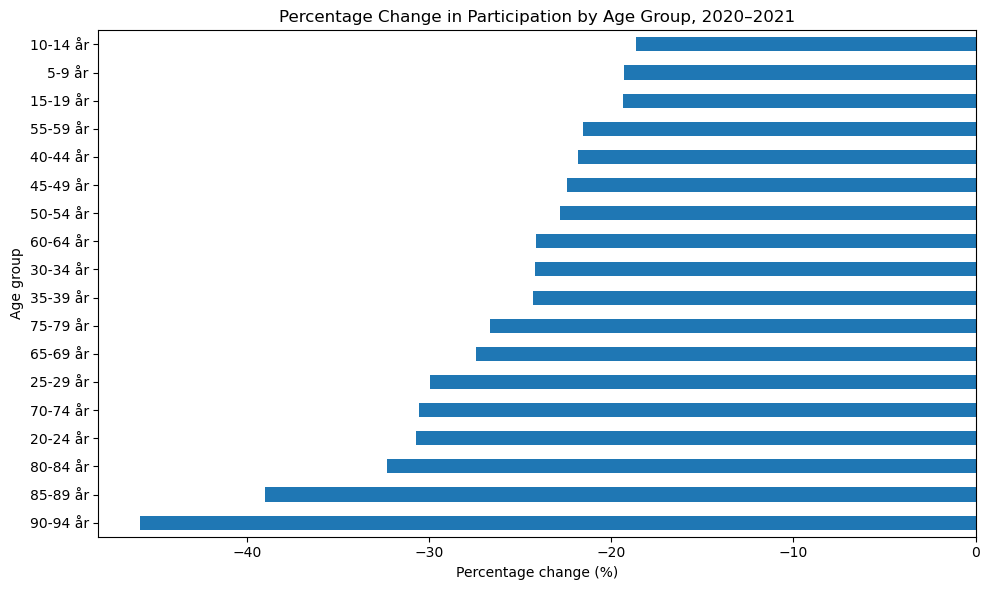

In [11]:
drop_2021_pct.plot(kind="barh", figsize=(10,6))
plt.title("Percentage Change in Participation by Age Group, 2020–2021")
plt.xlabel("Percentage change (%)")
plt.ylabel("Age group")
plt.tight_layout()
plt.show()

**Figure 3. Percentage change in participation by age group (2020–2021)**

The figure shows the decline in participation across age groups during the COVID-19 period.

Participation falls in every age group, but the largest percentage declines are observed among the oldest age groups, especially those aged 80 and above. Younger groups also experience clear declines, although the relative drop is smaller.

This suggests that the pandemic affected participation broadly, while having stronger relative effects on the groups most likely to be sensitive to health risks, distancing recommendations, and activity restrictions.

A simple stability measure is also calculated using the coefficient of variation (standard deviation divided by mean). Lower values indicate more stable participation over time.

The stability results show that participation is relatively stable for children, teenagers, and much of midlife, while variability is higher among young adults and the oldest age groups. This suggests that some parts of the life cycle are more sensitive than others to external shocks or changing life circumstances.

In [12]:
stability = (pivot_age.std() / pivot_age.mean()).sort_values()
stability

åldersgrupp
15-19 år    0.077828
10-14 år    0.078939
5-9 år      0.081645
40-44 år    0.086911
50-54 år    0.091778
55-59 år    0.091840
45-49 år    0.096143
30-34 år    0.099282
35-39 år    0.101985
60-64 år    0.102346
75-79 år    0.111147
65-69 år    0.114544
70-74 år    0.136906
20-24 år    0.143183
25-29 år    0.157895
80-84 år    0.158307
85-89 år    0.179135
90-94 år    0.207779
dtype: float64

A simple stability measure was also calculated using the coefficient of variation (standard deviation divided by mean). Lower values indicate more stable participation over time.

To test robustness, the life-cycle analysis was repeated excluding 2021, the year most clearly affected by the COVID-19 pandemic.

## Gender analysis

The gender analysis asks whether men and women follow the same broad age pattern, and whether participation levels differ systematically between them.

In [13]:
df_gender = df[
    (df["verksamhetsform"] == "Totalt") &
    (df["verksamhetsregion"] == "00 Riket") &
    (df["studieförbund"] == "Totalt") &
    (df["utbildningsnivå"] == "alla utbildningsnivåer") &
    (df["åldersgrupp"].isin(selected_ages)) &
    (df["kön"].isin(["män", "kvinnor"]))
].copy()



In [14]:
gender_total = df_gender.groupby(["år", "kön"])["Deltagare"].sum().unstack()
gender_ratio = gender_total["kvinnor"] / gender_total["män"]
gender_ratio, gender_total

(år
 2020    1.699276
 2021    1.768615
 2022    1.806879
 2023    1.847193
 2024    1.879910
 dtype: float64,
 kön    kvinnor       män
 år                      
 2020  453355.0  266793.0
 2021  342517.0  193664.0
 2022  406761.0  225118.0
 2023  422139.0  228530.0
 2024  408200.0  217138.0)

Women participate approximately 1.7–1.9 times more than men across the observed period, and the gap appears to increase slightly over time. This indicates a substantial and persistent difference in participation intensity.

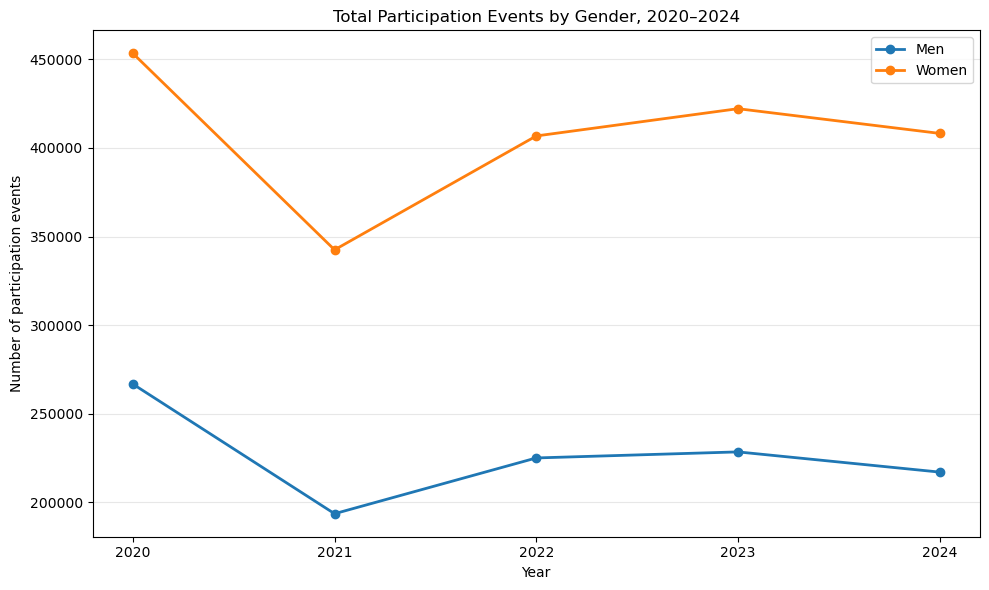

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(gender_total.index.astype(int), gender_total["män"], marker="o", linewidth=2, label="Men")
plt.plot(gender_total.index.astype(int), gender_total["kvinnor"], marker="o", linewidth=2, label="Women")

plt.title("Total Participation Events by Gender, 2020–2024")
plt.xlabel("Year")
plt.ylabel("Number of participation events")
plt.xticks(gender_total.index.astype(int))
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 4. Total participation events by gender (2020–2024)**

The figure shows total participation over time for men and women.

Women have higher participation levels than men in every year of the period. Both groups show a sharp decline in 2021, followed by recovery in later years.

This suggests that gender differences mainly affect the level of participation, while the overall temporal pattern is similar for both groups.

In [16]:
male_lifecycle = (
    df_gender[df_gender["kön"] == "män"]
    .groupby("åldersgrupp")["Deltagare"]
    .mean()
    .reindex(selected_ages)
)

female_lifecycle = (
    df_gender[df_gender["kön"] == "kvinnor"]
    .groupby("åldersgrupp")["Deltagare"]
    .mean()
    .reindex(selected_ages)
)

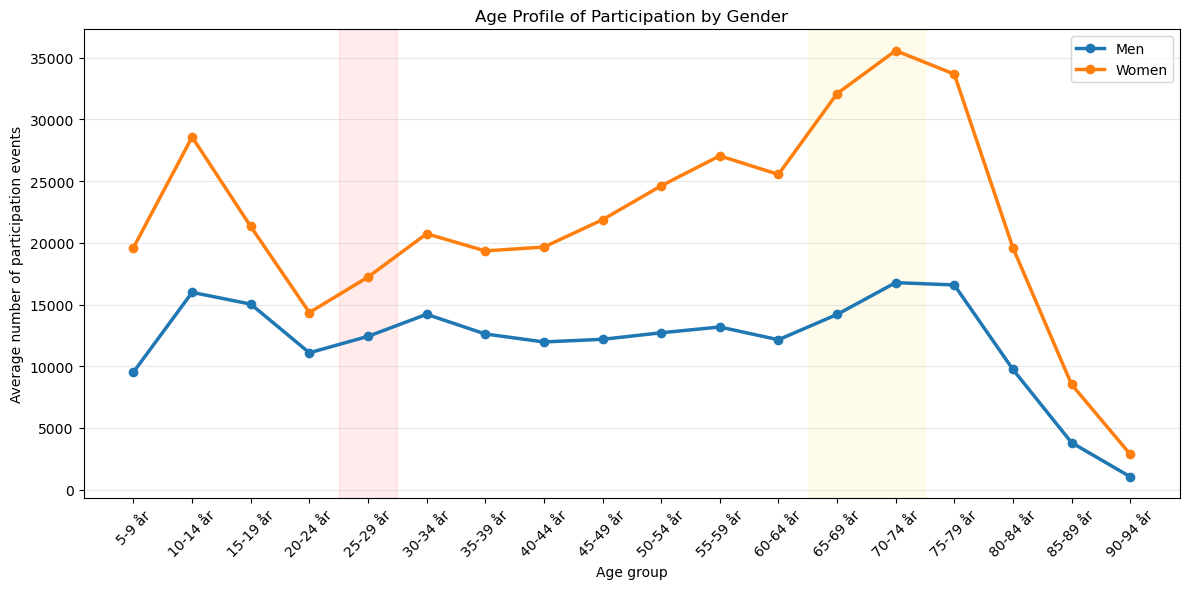

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(male_lifecycle.index, male_lifecycle.values, marker="o", linewidth=2.5, label="Men")
plt.plot(female_lifecycle.index, female_lifecycle.values, marker="o", linewidth=2.5, label="Women")

plt.title("Age Profile of Participation by Gender")
plt.xlabel("Age group")
plt.ylabel("Average number of participation events")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()

plt.axvspan(selected_ages.index("25-29 år") - 0.5, selected_ages.index("25-29 år") + 0.5,
            color="red", alpha=0.08)

plt.axvspan(selected_ages.index("65-69 år") - 0.5, selected_ages.index("70-74 år") + 0.5,
            color="gold", alpha=0.08)

plt.tight_layout()
plt.show()

**Figure 5. Age profile of participation by gender**

The figure compares participation patterns across age groups for men and women.

Both genders follow a similar life-cycle shape: relatively high participation in early adulthood, a decline around 25–29, and a rise again in older age groups. However, women display higher participation levels across the full age profile.

This implies that age structures the general pattern of participation, while gender is associated primarily with systematic differences in participation intensity.

### Statistical check of the gender difference

In [18]:
from scipy import stats

male_values = gender_total["män"]
female_values = gender_total["kvinnor"]

t_stat, p_value = stats.ttest_ind(female_values, male_values, equal_var=False)

t_stat, p_value

(8.349075155541101, 7.563312748288201e-05)

A Welch two-sample t-test was used as a simple statistical check of whether participation levels differ systematically between women and men over the observed period.

The test indicates a statistically significant difference in average participation events between the two groups (t ≈ 8.35, p < 0.001), with women showing consistently higher participation levels.

This result should, however, be interpreted with caution. The number of observations is very small, since the comparison is based on annual totals over only five years. In addition, the observations are aggregated at the population level rather than drawn from individual-level data.

For that reason, the t-test should not be viewed as a strong inferential result on its own. Its main value here is to support what is already clearly visible in the descriptive analysis: the gender gap is large, persistent, and unlikely to reflect random year-to-year fluctuation alone.

## Education analysis

The education analysis examines whether participation differs across education levels and whether those differences vary across the adult life course.

Unlike the age and gender sections, this part removes aggregate and missing education categories in order to compare meaningful education groups directly.

A key methodological caution is needed here: for younger adults, especially those aged 20–24, observed education categories do not necessarily represent completed educational attainment. Many individuals in this group are still in education. As a result, education differences at younger ages should be interpreted more cautiously than differences later in adulthood.

In [19]:
df_edu_total = df[
    (df["verksamhetsform"] == "Totalt") &
    (df["verksamhetsregion"] == "00 Riket") &
    (df["studieförbund"] == "Totalt") &
    (df["åldersgrupp"] == "samtliga åldrar") &
    (df["kön"] == "totalt") &
    (~df["utbildningsnivå"].isin(["alla utbildningsnivåer", "uppgift saknas"]))
].copy()

In [20]:
edu_total = df_edu_total.groupby("utbildningsnivå")["Deltagare"].mean().sort_values(ascending=False)


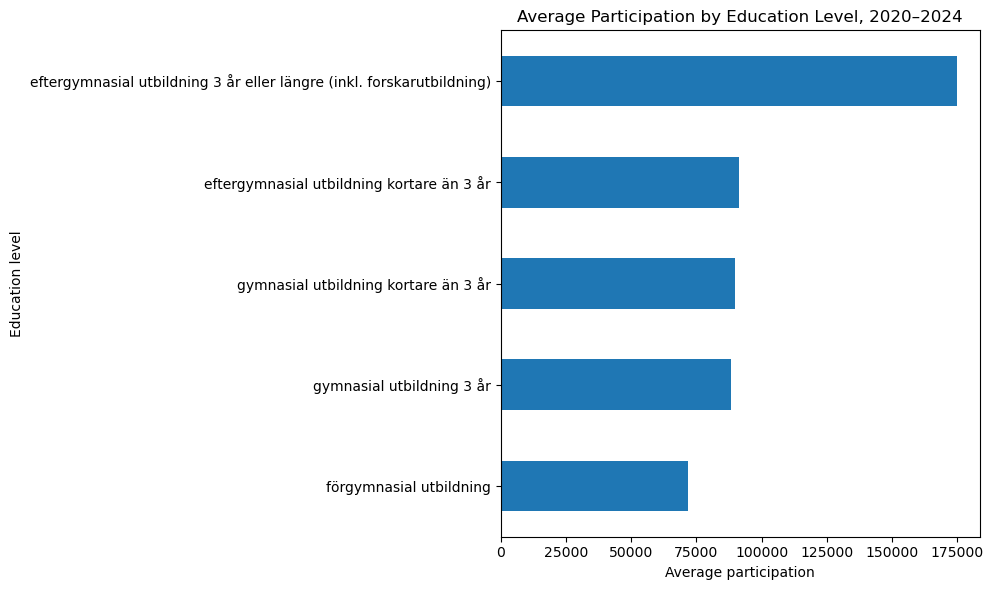

In [21]:
edu_total.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Average Participation by Education Level, 2020–2024")
plt.xlabel("Average participation")
plt.ylabel("Education level")
plt.tight_layout()
plt.show()

**Figure 6. Average participation by education level (2020–2024)**

The figure shows average participation across education levels.

Participation is highest among individuals with longer post-secondary education, and lower among groups with lower formal educational attainment.

This indicates a strong descriptive association between education level and participation intensity. The pattern may reflect differences in social networks, cultural participation habits, access to resources, or broader forms of social engagement. However, the analysis does not identify which of these mechanisms is most important.

In [22]:
selected_edu = [
    "förgymnasial utbildning",
    "gymnasial utbildning 3 år",
    "eftergymnasial utbildning 3 år eller längre (inkl. forskarutbildning)"
]

selected_ages_edu = [
    "20-24 år", "25-29 år", "30-34 år",
    "35-39 år", "40-44 år", "45-49 år",
    "50-54 år", "55-59 år", "60-64 år"
]

df_edu_age = df[
    (df["verksamhetsform"] == "Totalt") &
    (df["verksamhetsregion"] == "00 Riket") &
    (df["studieförbund"] == "Totalt") &
    (df["kön"] == "totalt") &
    (df["utbildningsnivå"].isin(selected_edu)) &
    (df["åldersgrupp"].isin(selected_ages_edu))
].copy()

In [23]:
pivot_edu_age = df_edu_age.pivot_table(
    index="åldersgrupp",
    columns="utbildningsnivå",
    values="Deltagare",
    aggfunc="mean"
).reindex(selected_ages_edu)



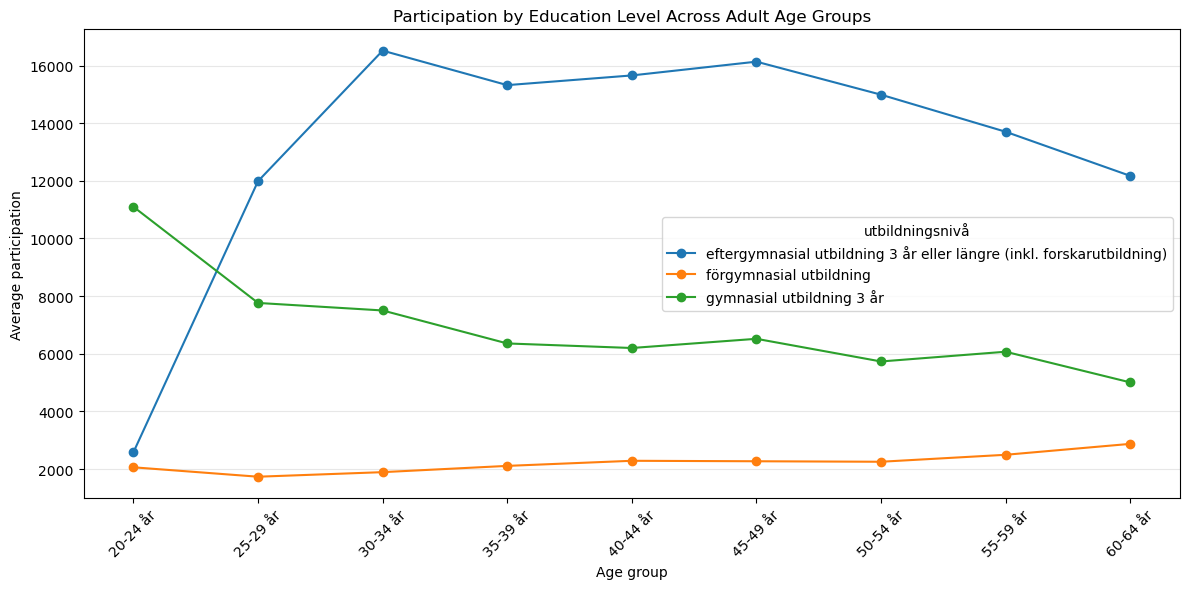

In [24]:
pivot_edu_age.plot(figsize=(12, 6), marker="o")
plt.title("Participation by Education Level Across Adult Age Groups")
plt.xlabel("Age group") 
plt.ylabel("Average participation")
plt.xticks(rotation=45) 
plt.grid(True, axis="y", alpha=0.3) 
plt.tight_layout() 
plt.show()

**Figure 7. Participation by education level across adult age groups**

The figure shows how participation differs by education level across adult age groups.

Higher education is associated with substantially higher participation across most adult age groups, especially from the late twenties through midlife. The pattern is fairly persistent rather than concentrated in only one part of adulthood.

At younger ages, especially 20–24, the relationship looks different. This likely reflects ongoing educational transitions: many individuals in this age group have not yet completed their final level of education. Education categories at these ages therefore capture current position as much as completed attainment.

Overall, the figure suggests that participation is structured not only by life stage, but also by educational background. At the same time, the interpretation is strongest in the age groups where education level is more likely to reflect completed attainment.

## Key findings

The analysis produces five main findings:

1. Participation follows a clear life-cycle pattern, with peaks in early adulthood and around retirement age.
2. The sharpest decline occurs in the transition from education to early working life, especially around ages 25–29.
3. Women generate more participation events than men across all age groups.
4. Higher education is associated with substantially higher participation levels.
5. The COVID-19 shock affected participation levels strongly, but did not fundamentally alter the broader age structure of participation.

## Why no model is fitted (analytical choice)

At this stage, one could attempt to fit a statistical model to describe the relationship between age and participation, or between education and participation.

However, this approach is intentionally not pursued.

The observed pattern does not reflect a single continuous process. Instead, it captures distinct life-cycle phases such as education, labor market entry, and retirement.

Because of this, there is no strong theoretical reason to expect a simple functional relationship between age and participation. Any fitted model would mainly reproduce the shape of the data without providing meaningful explanation.

More flexible models (e.g., higher-degree polynomials) could improve visual fit, but would risk overfitting and incorrectly suggesting a smooth and continuous structure.

For this reason, the analysis remains descriptive and focuses on identifying structural patterns rather than estimating causal relationships.

## Limitations

This project has several important limitations.

First, the data measures participation events, not unique individuals. Higher values may therefore reflect more frequent participation rather than a larger number of participants.

Second, the age analysis is cross-sectional. It compares age groups at a given time rather than following the same individuals over the life course.

Third, the analysis is descriptive and does not identify causal mechanisms. The observed patterns may reflect multiple overlapping processes, including education, labor market position, retirement, health, institutional access, and social norms.

Fourth, education is more difficult to interpret in younger adult groups, because educational attainment is often not yet complete.

Finally, children and adults may participate under quite different institutional conditions, so comparisons across the full life course should be interpreted with some caution.

## Why this matters: policy and practical implications

Understanding participation patterns in study association activities is relevant for cultural policy, public funding, and social inclusion.

The analysis shows that participation is not evenly distributed across the population. Instead, it varies systematically by age, gender, and education. This matters because publicly supported educational and cultural activities are often expected to reach broad and diverse groups.

Several implications follow from the results.

First, the sharp decline around ages 25–29 highlights a critical transition point where participation weakens substantially. This suggests that early adulthood may be an important stage for targeted efforts aimed at maintaining engagement during the transition into work and family life.

Second, the rise in participation around retirement age indicates that study association activities may play an important role in active ageing, lifelong learning, and social connectedness among older adults.

Third, the persistent gender gap suggests that participation is structured in ways that do not affect all groups equally. Women participate more than men across the full age profile, which may indicate differences in access, preferences, time use, or institutional fit.

Fourth, the strong association between education and participation suggests that these activities may reflect, and potentially reinforce, broader social inequalities in access to cultural and educational engagement.

Finally, the COVID-19 results show that external shocks can strongly reduce participation levels, especially among older groups, even when the broader life-cycle structure remains intact. This makes the findings relevant not only for routine policy design, but also for resilience and recovery planning.

Taken together, the results provide descriptive evidence that can support more informed decisions about outreach, accessibility, inclusion, and the allocation of public resources.

## Conclusion

This project shows that participation in Swedish study association activities is systematically patterned by age, gender, and education.

The most prominent result is a clear life-cycle structure: participation is relatively high in early adulthood, falls during the transition into work and family formation, remains moderate through much of midlife, rises again around retirement age, and declines in the oldest age groups.

Gender and education are associated with substantial differences in participation levels, but they do not overturn the broader age-related structure. The COVID-19 shock in 2021 produced a large temporary decline, yet the underlying life-cycle pattern remained visible even when that year is excluded.

Taken together, these findings provide a strong descriptive basis for understanding how different groups engage in publicly supported educational and cultural activities in Sweden. More broadly, they suggest that participation is shaped by enduring social structure and life-stage transitions, making this type of analysis relevant for both cultural policy and questions of social inclusion.

## Next analytical steps

If more detailed data were available, the analysis could be extended by:

- Adjusting participation by population size (per capita analysis)  
- Using individual-level data to separate participation frequency from participation rates  
- Estimating statistical models to quantify the relationship between age, education, and participation  
- Incorporating income or socio-economic variables to better understand inequality patterns  

## Appendix: Supplementary analysis


The figures below provide additional detail on recovery patterns, gender-specific pandemic effects, and education trends over time. These results support the main analysis but are not necessary to establish its central conclusions.

In [25]:
recovery_23 = ((pivot_age.loc[2023] - pivot_age.loc[2021]) / pivot_age.loc[2021]) * 100
recovery_24 = ((pivot_age.loc[2024] - pivot_age.loc[2021]) / pivot_age.loc[2021]) * 100

comparison = pd.DataFrame({
    "Recovery_2023 (%)": recovery_23,
    "Recovery_2024 (%)": recovery_24
})



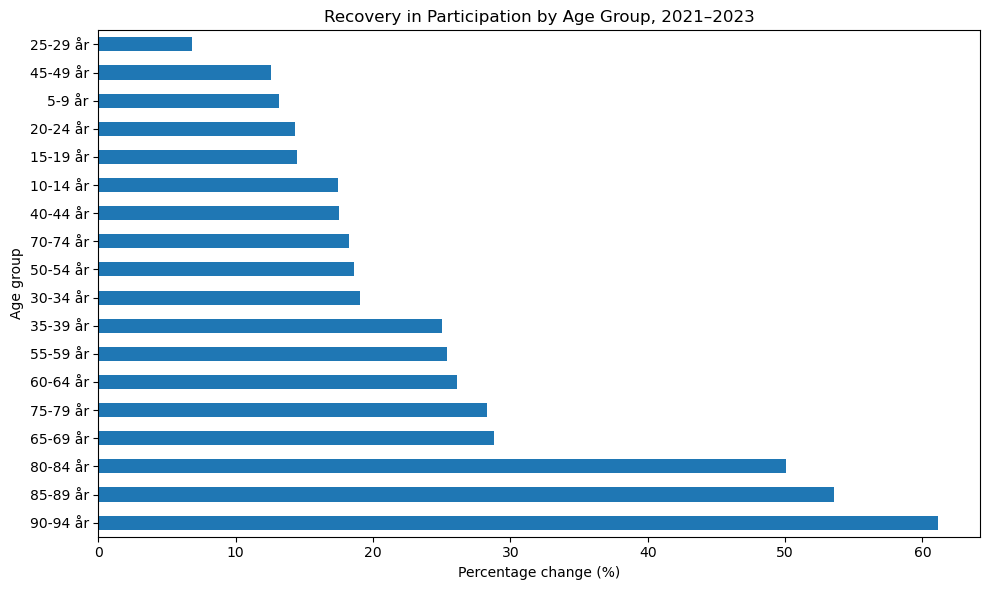

In [26]:
recovery_23.sort_values(ascending=False).plot(kind="barh", figsize=(10,6))
plt.title("Recovery in Participation by Age Group, 2021–2023")
plt.xlabel("Percentage change (%)")
plt.ylabel("Age group")
plt.tight_layout()
plt.show()

**Figure A1. Recovery in participation by age group (2021–2023)**

The figure shows recovery after the COVID-19 decline.

Older age groups exhibit the strongest recovery, while younger adults, especially those aged 25–29, show much weaker recovery.

This suggests that post-pandemic participation dynamics differ substantially across the life course. The main divide is not between men and women, but between age groups.

In [27]:
drop_2021_gender = {}

for gender in ["män", "kvinnor"]:
    temp = (
        df_gender[df_gender["kön"] == gender]
        .pivot_table(index="år", columns="åldersgrupp", values="Deltagare", aggfunc="sum")
        .reindex(columns=selected_ages)
    )
    drop_2021_gender[gender] = ((temp.loc[2021] - temp.loc[2020]) / temp.loc[2020]) * 100

drop_2021_gender_df = pd.DataFrame(drop_2021_gender)


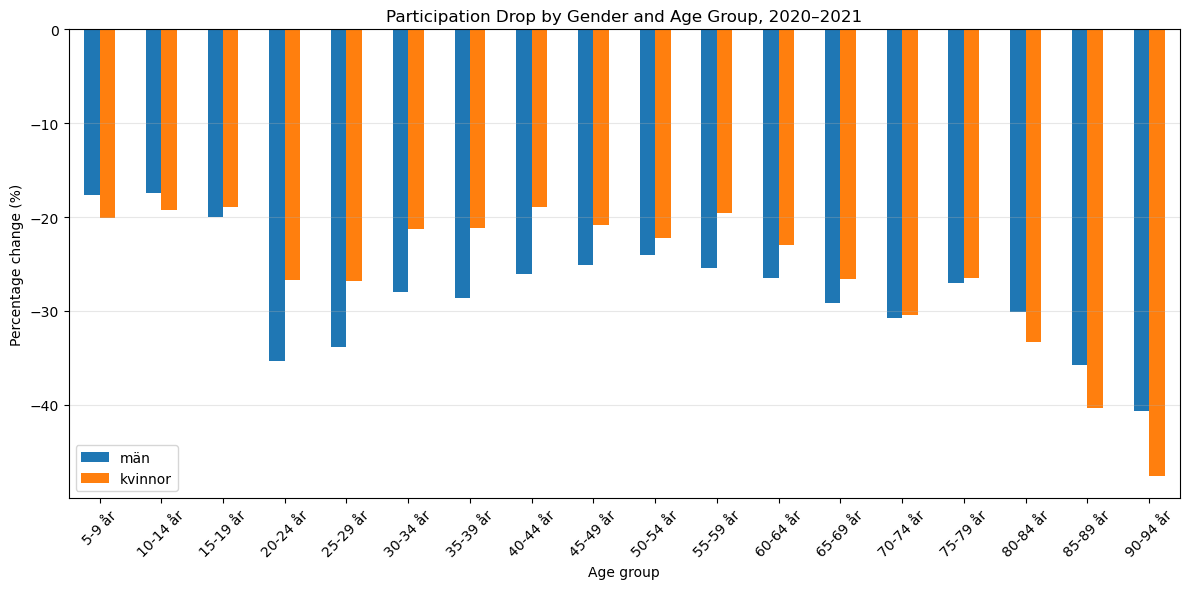

In [28]:
ax = drop_2021_gender_df.plot(kind="bar", figsize=(12,6))
ax.set_title("Participation Drop by Gender and Age Group, 2020–2021")
ax.set_ylabel("Percentage change (%)")
ax.set_xlabel("Age group")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Figure A2. Participation drop by gender and age group (2020–2021)**

The figure shows how participation declined for men and women across age groups between 2020 and 2021.

All groups experienced negative change, with larger declines among older individuals. In several age groups, men show somewhat larger declines than women, although the broad pattern is similar for both.

This suggests that the pandemic shock was broad-based, with age playing the dominant role and gender differences appearing as a secondary pattern.

In [29]:
recovery_gender = {}

for gender in ["män", "kvinnor"]:
    temp = (
        df_gender[df_gender["kön"] == gender]
        .pivot_table(index="år", columns="åldersgrupp", values="Deltagare", aggfunc="sum")
        .reindex(columns=selected_ages)
    )
    recovery_gender[gender] = ((temp.loc[2024] - temp.loc[2021]) / temp.loc[2021]) * 100

recovery_gender_df = pd.DataFrame(recovery_gender)


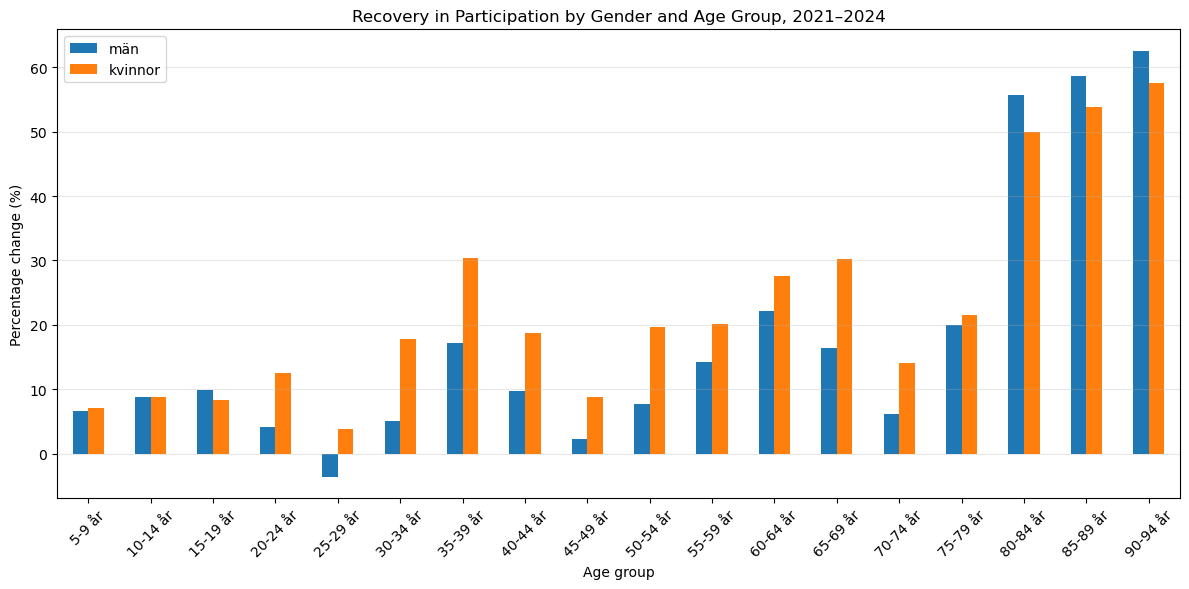

In [30]:
ax = recovery_gender_df.plot(kind="bar", figsize=(12,6))
ax.set_title("Recovery in Participation by Gender and Age Group, 2021–2024")
ax.set_ylabel("Percentage change (%)")
ax.set_xlabel("Age group")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Figure A3. Recovery in participation by gender and age group (2021–2024)**

The figure shows how participation recovered for men and women across age groups between 2021 and 2024.

Recovery increases strongly with age, with the largest gains observed among individuals aged 80 and above. Younger groups show only modest recovery, while the 25–29 age group stands out as particularly weak, especially among men.

Women generally exhibit somewhat stronger recovery than men across many age groups, but age remains the dominant factor shaping the overall pattern.

Taken together, these results suggest that post-pandemic recovery is primarily structured by age rather than gender.



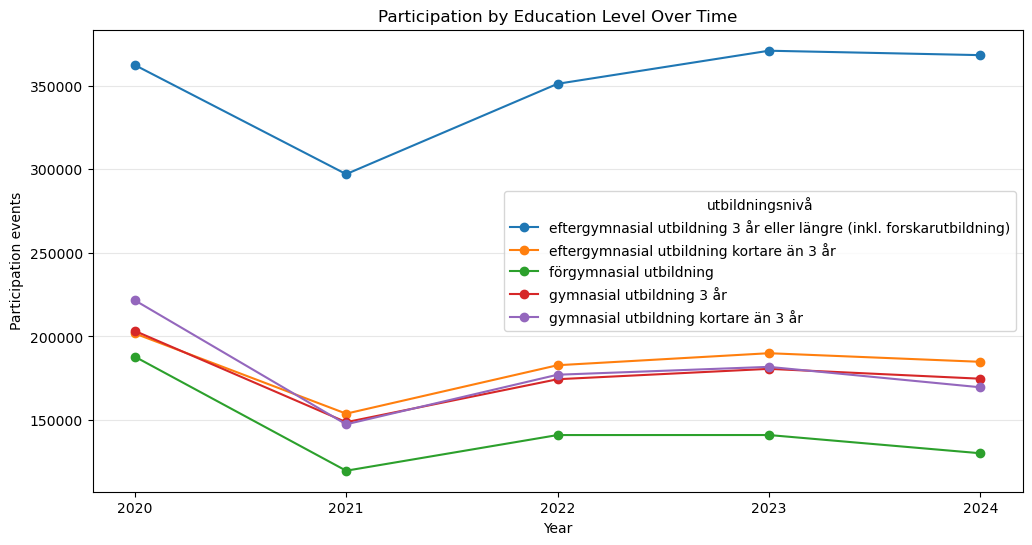

In [31]:
df_edu_total["år"] = pd.to_numeric(df_edu_total["år"], errors="coerce").astype(int)

pivot_edu_time = df_edu_total.pivot_table(
    index="år",
    columns="utbildningsnivå",
    values="Deltagare",
    aggfunc="sum"
).sort_index()

# Convert index to plain Python/numpy ints
years = pivot_edu_time.index.to_numpy(dtype=int)

ax = pivot_edu_time.plot(figsize=(12, 6), marker="o")

ax.set_title("Participation by Education Level Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Participation events")
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=0)

plt.grid(True, axis="y", alpha=0.3)
plt.show()

**Figure A4. Participation by education level over time**

The figure shows participation trends across education levels over time.

All education groups experience a decline in 2021 followed by recovery. Groups with higher education consistently display higher participation levels throughout the period.

This indicates that education is associated with persistent differences in participation levels, while the broader year-to-year pattern is shaped by external shocks affecting all groups.

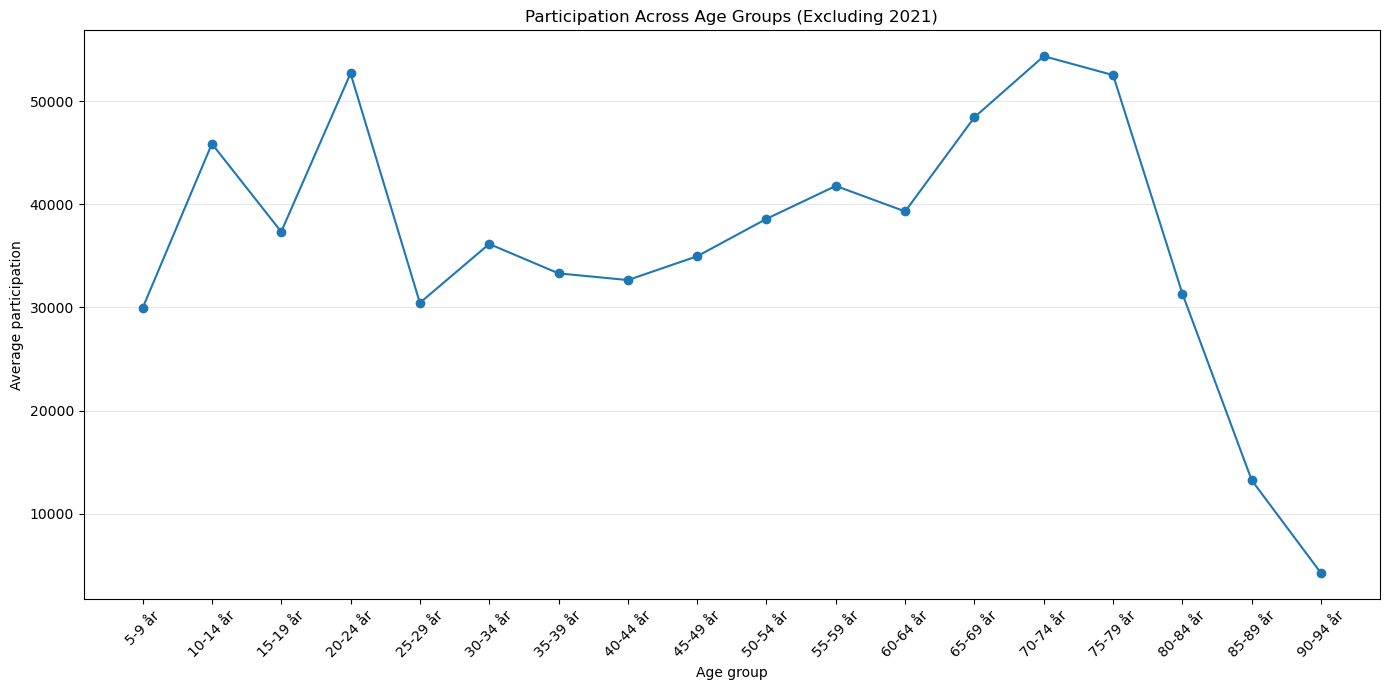

In [32]:
pivot_no_covid = pivot_age.drop(index=2021)

lifecycle_no_covid = pivot_no_covid.mean()
lifecycle_no_covid = lifecycle_no_covid[selected_ages]

x = np.arange(len(lifecycle_no_covid))
y = lifecycle_no_covid.values

plt.figure(figsize=(14, 7))
plt.plot(x, y, marker="o")
plt.title("Participation Across Age Groups (Excluding 2021)")
plt.xticks(x, lifecycle_no_covid.index, rotation=45)
plt.ylabel("Average participation")
plt.xlabel("Age group")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Figure A5. Participation across age groups excluding 2021**

The figure shows the life-cycle pattern after excluding 2021, the year most clearly affected by the pandemic.

The overall shape remains very similar: participation is high in early adulthood, drops around 25–29, rises again in older age, and declines in the oldest groups.

This supports the interpretation that the age profile is not merely a temporary pandemic artifact. Instead, the COVID-19 shock appears to have affected participation levels while leaving the broader underlying structure largely intact.


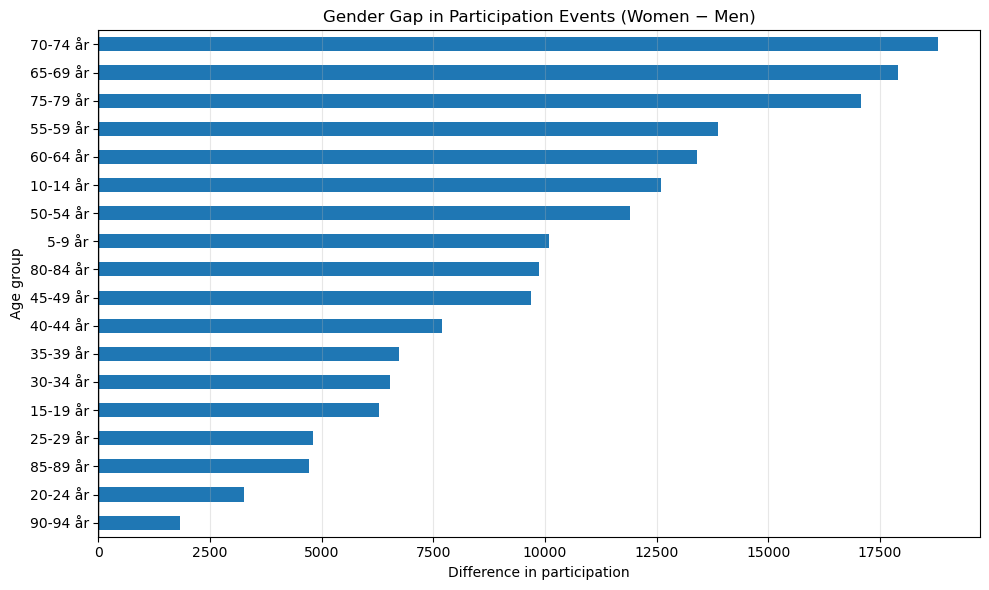

In [33]:
gender_gap = female_lifecycle - male_lifecycle
gender_gap.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Gender Gap in Participation Events (Women − Men)")
plt.xlabel("Difference in participation")
plt.ylabel("Age group")
plt.axvline(0, color="black", linewidth=1)
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Figure A6. Gender gap in participation (women minus men)**
The figure shows the difference in participation between women and men across age groups.

The gap is positive in all age groups, indicating that women participate more than men throughout the life cycle. The largest differences appear in older age groups.

This reinforces the conclusion that the gender difference is persistent rather than limited to a small set of age categories. At the same time, the similar shape of the male and female curves suggests that the underlying age pattern is shared.

In [34]:
stability_gender = {}

for gender in ["män", "kvinnor"]:
    temp = (
        df_gender[df_gender["kön"] == gender]
        .pivot_table(index="år", columns="åldersgrupp", values="Deltagare", aggfunc="sum")
        .reindex(columns=selected_ages)
    )
    stability_gender[gender] = temp.std() / temp.mean()

stability_gender_df = pd.DataFrame(stability_gender)
stability_gender_df.round(3)

,män,kvinnor
åldersgrupp,,
5-9 år,0.073,0.086
10-14 år,0.076,0.081
15-19 år,0.080,0.076
20-24 år,0.187,0.113
25-29 år,0.203,0.127
30-34 år,0.131,0.088
35-39 år,0.121,0.103
40-44 år,0.114,0.079
45-49 år,0.121,0.085


**Table A7. Stability of participation across age groups and gender**

The table reports the coefficient of variation, measuring how stable participation is over time.

Participation is most stable among children, teenagers, and parts of midlife, while variability is highest among young adults aged 20–29 and in the oldest age groups. Among young adults, variability is particularly pronounced for men.

This suggests that participation is most sensitive to change during early adulthood and late old age, whereas other life stages are comparatively more stable.